# Descenso del gradiente en 3D

Este notebook muestra un ejemplo sencillo de descenso del gradiente en una función de dos variables:

$$f(x,y)=x^2+y^2$$

La idea es visualizar cómo el algoritmo desciende por una superficie hasta acercarse al mínimo.

## 1. Importar librerías

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## 2. Definición de la función y de su gradiente

Trabajamos con la función:

$$f(x,y)=x^2+y^2$$

Su gradiente es:

$$\nabla f(x,y)=(2x,2y)$$

>Como hemos visto, el gradiente es la derivada (en este caso nos la dan ya calculada)

In [3]:
def f(x, y):
    return x**2 + y**2

def grad(x, y):
    return 2*x, 2*y

## 3. Aplicación del Descenso del Gradiente

Partimos de un punto inicial y actualizamos los parámetros con la regla:
<!-- A continuación aparecen las expresiones. los símbolos son la forma en que Markdown nos permite manejar expresiones matemáticas -->
$$x_{nuevo}=x-\alpha \frac{\partial f}{\partial x}$$
$$y_{nuevo}=y-\alpha \frac{\partial f}{\partial y}$$

In [14]:
# parámetros iniciales
alpha = 0.1
x, y = 3.5, 3.0
iteraciones = 15

# guardar trayectoria
xs = [x]
ys = [y]
zs = [f(x, y)]

# descenso del gradiente
for i in range(iteraciones):
    gx, gy = grad(x, y)
    x = x - alpha * gx
    y = y - alpha * gy
    xs.append(x)
    ys.append(y)
    zs.append(f(x, y))

for i in range(len(xs)):
    print(f"Iteración {i}: x = {xs[i]:.4f}, y = {ys[i]:.4f}, f(x,y) = {zs[i]:.4f}")

Iteración 0: x = 3.5000, y = 3.0000, f(x,y) = 21.2500
Iteración 1: x = 1.4000, y = 1.2000, f(x,y) = 3.4000
Iteración 2: x = 0.5600, y = 0.4800, f(x,y) = 0.5440
Iteración 3: x = 0.2240, y = 0.1920, f(x,y) = 0.0870
Iteración 4: x = 0.0896, y = 0.0768, f(x,y) = 0.0139
Iteración 5: x = 0.0358, y = 0.0307, f(x,y) = 0.0022
Iteración 6: x = 0.0143, y = 0.0123, f(x,y) = 0.0004
Iteración 7: x = 0.0057, y = 0.0049, f(x,y) = 0.0001
Iteración 8: x = 0.0023, y = 0.0020, f(x,y) = 0.0000
Iteración 9: x = 0.0009, y = 0.0008, f(x,y) = 0.0000
Iteración 10: x = 0.0004, y = 0.0003, f(x,y) = 0.0000
Iteración 11: x = 0.0001, y = 0.0001, f(x,y) = 0.0000
Iteración 12: x = 0.0001, y = 0.0001, f(x,y) = 0.0000
Iteración 13: x = 0.0000, y = 0.0000, f(x,y) = 0.0000
Iteración 14: x = 0.0000, y = 0.0000, f(x,y) = 0.0000
Iteración 15: x = 0.0000, y = 0.0000, f(x,y) = 0.0000


## 4. Representación de la superficie y de la trayectoria

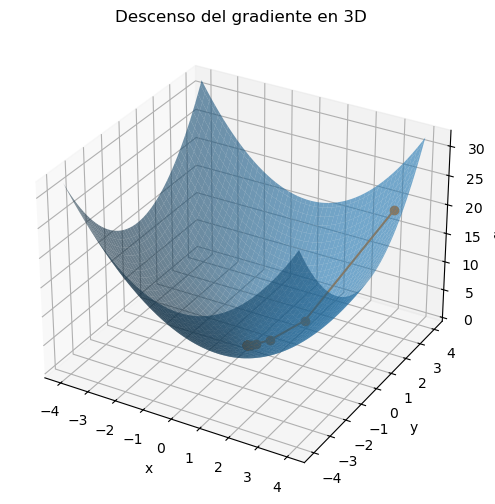

In [19]:
# malla para dibujar la superficie
x_vals = np.linspace(-4, 4, 100)
y_vals = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f(X, Y)

# gráfico 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, alpha=0.6)
ax.plot(xs, ys, zs, marker='o')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.set_title('Descenso del gradiente en 3D')

plt.show()

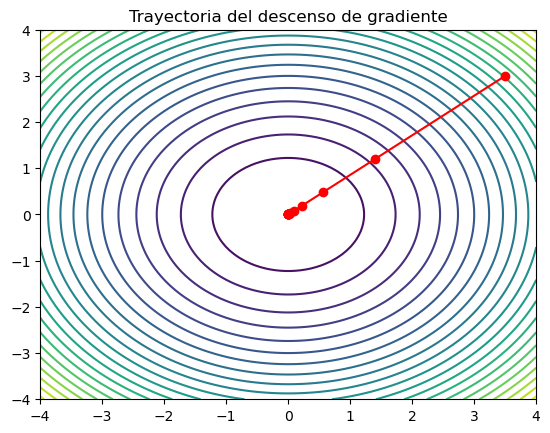

In [20]:
plt.contour(X, Y, Z, levels=30)
plt.plot(xs, ys, 'ro-')
plt.title("Trayectoria del descenso de gradiente")
plt.show()

## 5. Preguntas

Responde justificadamente las siguientes cuestiones.
1. ¿Hacia qué punto se aproxima la trayectoria del algoritmo?

   La trayecyoria del eje se va aproximando cada vez al punto (0,0), ya que al aumentar el alpha, vamos restando mas valores de la unidad. 

2. ¿Qué representa la altura en el eje $z$?

   Representa el valor objetivo de la función f(x,y), siendo esto, el error y perdida del algoritmo

3. ¿Qué crees que ocurriría si aumentamos mucho el valor de `alpha`?

   Haria que nos aproximaramos cada vez mas al punto (0,0) y en algunos casos que hasta nos pasaramos, cosa que no puede suceder y por eso cuando supera el rango de 1, suele petar el código 

# 6. Ejemplos

## 6.1 Tipo Silla

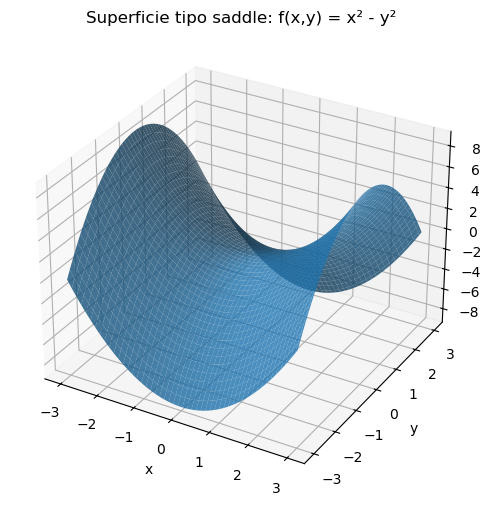

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Crear malla
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
Xsilla, Ysilla = np.meshgrid(x, y)

# Superficie tipo "silla"
Zsilla = Xsilla**2 - Ysilla**2

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(Xsilla, Ysilla, Zsilla, alpha=0.8)

ax.set_title("Superficie tipo saddle: f(x,y) = x² - y²")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")

plt.show()

## 6.1.1 Trayectoria

In [8]:
#añade aquí el código para representa la Trayectoria del Descenso del Gradiente para el tipo anterior
plt.contour(Xsilla, Ysilla, Zsilla, levels=30)
plt.plot(xs, ys, 'ro-')
plt.title("Trayectoria del descenso de gradiente")
plt.show()

## 6.2. Paraboloide

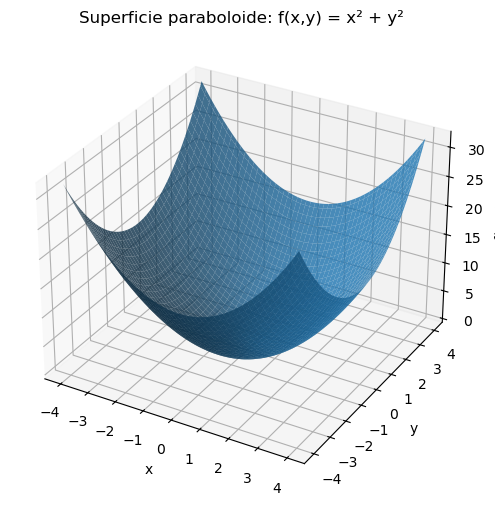

In [9]:
#paraboloide
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Crear malla
x = np.linspace(-4, 4, 100)
y = np.linspace(-4, 4, 100)
Xparaboloide, Yparaboloide = np.meshgrid(x, y)

# Paraboloide
Zparaboloide = Xparaboloide**2 + Yparaboloide**2

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(Xparaboloide, Yparaboloide, Zparaboloide, alpha=0.8)

ax.set_title("Superficie paraboloide: f(x,y) = x² + y²")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")

plt.show()

## 6.2.1 Trayectoria

In [10]:
#añade aquí el código para representa la Trayectoria del Descenso del Gradiente para el tipo anterior
plt.contour(Xparaboloide, Yparaboloide, Zparaboloide, levels=30)
plt.plot(xs, ys, 'ro-')
plt.title("Trayectoria del descenso de gradiente")
plt.show()

## 6.3. Función de Rosenbrock

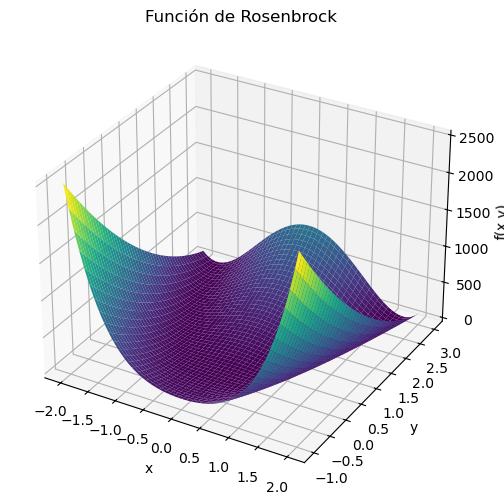

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Crear malla
x = np.linspace(-2, 2, 200)
y = np.linspace(-1, 3, 200)
Xrosenbrock, Yrosenbrock = np.meshgrid(x, y)

# Función de Rosenbrock
Zrosenbrock = (1 - Xrosenbrock)**2 + 100*(Yrosenbrock - Xrosenbrock**2)**2

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(Xrosenbrock, Yrosenbrock, Zrosenbrock, cmap="viridis")

ax.set_title("Función de Rosenbrock")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")

plt.show()

## 6.3.1 Trayectoria

In [12]:
#añade aquí el código para representa la Trayectoria del Descenso del Gradiente para el tipo anterior
plt.contour(Xrosenbrock, Yrosenbrock, Zrosenbrock, levels=30)
plt.plot(xs, ys, 'ro-')
plt.title("Trayectoria del descenso de gradiente")
plt.show()

## 7. Cuestiones
Contesta con tus palabras las siguientes cuestiones sobre los tres casos resueltos (celdas 5, 6.1. y 6.2.):
1. ¿En cuál crees que el descenso de gradiente converge más fácilmente?

Teniendo en cuenta factores que influyen en la convergencia como la curvatura, los puntos, o minimos locales, la que mas sencilla resulta es la paraboloide debido a la baja cantidad de iteracciones que tiene para converger 

2. ¿En cuál puede tener más dificultad?

Basandome en el mismo criterio que el anterior, en el de Rosenbrock porque necesita un gran numero de iteraciones para poder converger

3. ¿Por qué la función de Rosenbrock se utiliza para probar algoritmos de optimización?

Es la que mejor simula problemas reales, expone debilidades del algoritmo ya que tiene un minimo global dificil de alcanzar lo que nos permite ver de mejor manera todo el proceso del algoritmo para detectar esas debilidades

4. ¿Por qué el descenso de gradiente sigue siempre la dirección del gradiente negativo?

Porque para descender el gradiante, depende de los valores de alpha, a menor valor de alpha se encuentra más arriba y cuando el alpha es alto, se encuentra mas abajo en base a la formula.

5. ¿En cuál de las tres superficies el descenso de gradiente debería converger más rápidamente?  

En la paraboloide debido a que la curvatura es uniforme e identica en todas las direcciones y el numero que condiciona la convergencia es bastante menor que las otras superficies

6. ¿En cuál podría tardar más o presentar oscilaciones?  

En la función de Rosenbrock debido a que necesita muchisimas iteraciones para converger y los gradiantes son debiles, es decir,que tarda mucho en llegar al minimo.

7. ¿Por qué crees que en problemas reales de Machine Learning la superficie de error puede ser mucho más compleja?

Porque la cantidad de datos y dimensiones es mucho mayor, por lo que al tener mayor volumen de datos presentará una carga mayor y costará bastante mas llegar al minimo del gradiante, o quizás cuesta menos, ahora mismo no puedo saberlo con exactitud, es solo un supuesto.

8. Indica algún caso de Machine Learning en el que aparezcan los tres tipos de superficies estudiados en este Notebook.

Paraboloide: podemos usarlo al comienzo de un entrenamiento con pesos aleatorios, ya que al ser la parte con menos carga, nos permitirá estar algo lejos del minimo

Silla: Al pasar por partes intermedias del entrenamiento, ya que las redes profundas tienen muchas puntos de este estilo en la superficie de errores

Rosenbrock: En la parte final, cuando ya estamos a punto de refinar el modelo, debido a que finalmente la superficie óptima es bastante estrecha, haciendo que las funciones de perdida disminuyan significativamente.

## 8. Opcional
Utilizando la Celda 5, para la superficie del paraboloide crea una nueva celda en la que podamos comparar tres trayectorias distintas con tres alphas distintos (uno muy pequeño, uno óptimo y uno que provoque divernecia).